# Notebook 07 — Final Dashboard & Summary

## Human-to-Gorilla Zoonotic Disease Transmission Risk Analysis

---

### Purpose
Produce the **final publication-quality dashboard** and **executive summary** of all findings.

This notebook:
1. Assembles all key findings into a single multi-panel figure
2. Produces an interactive Plotly dashboard
3. Generates the final written summary
4. Verifies all output files exist

---

### Key Findings Summary
_(Populated from analysis — verify against your actual output values)_

1. **Age susceptibility**: Infants and silverbacks had 2–3× higher illness incidence than prime-age adults (Kruskal-Wallis, significant after Bonferroni correction)
2. **Tourism linkage**: ~15–25% of gorilla illness events were temporally linked to symptomatic tourist visits (14-day window, group-controlled)
3. **Seasonal independence**: Illness rates were significantly higher in wet seasons (Kruskal-Wallis p<0.001), demonstrating that environmental factors independently drive illness
4. **Mother-to-infant pathway**: Identified as a key intra-group transmission pathway, distinct from tourism events
5. **Risk model AUC**: ~0.75–0.85, indicating moderate predictive power for tourism attribution
6. **Policy impact**: Combined masking + strict screening modeled to reduce P(tourism-attributed) by 30–50%

## Cell 1 — Imports

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns

try:
    import plotly.graph_objects as go
    import plotly.express as px
    from plotly.subplots import make_subplots
    PLOTLY_AVAILABLE = True
except ImportError:
    print('Plotly not available — skipping interactive plots')
    PLOTLY_AVAILABLE = False

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.viz_utils import set_style, save_fig, PALETTE, AGE_ORDER

set_style()

RAW_DIR  = PROJECT_ROOT / 'data' / 'raw'
PROC_DIR = PROJECT_ROOT / 'data' / 'processed'
FIG_DIR  = PROJECT_ROOT / 'outputs' / 'figures'
RPT_DIR  = PROJECT_ROOT / 'outputs' / 'reports'

print('Final dashboard notebook ready.')

Plotly not available — skipping interactive plots
Final dashboard notebook ready.


## Cell 2 — Load All Results

In [2]:
# Load processed data
linked_df         = pd.read_csv(PROC_DIR / 'gorilla_health_linked.csv', parse_dates=['event_date'])
gorilla_enriched  = pd.read_csv(PROC_DIR / 'gorilla_health_enriched.csv', parse_dates=['event_date'])
daily_summary_df  = pd.read_csv(PROC_DIR / 'daily_summary.csv', parse_dates=['date'])
gorilla_health_df = pd.read_csv(RAW_DIR / 'gorilla_health_events.csv', parse_dates=['event_date'])
tourist_health_df = pd.read_csv(RAW_DIR / 'tourist_health_records.csv', parse_dates=['visit_date'])
demographics_df   = pd.read_csv(RAW_DIR / 'gorilla_demographics.csv')
climate_df        = pd.read_csv(RAW_DIR / 'seasonal_climate_data.csv', parse_dates=['date'])

# Load model outputs if they exist
try:
    coef_df    = pd.read_csv(RPT_DIR / 'model_coefficients.csv')
    scenario_df = pd.read_csv(RPT_DIR / 'policy_scenario_results.csv')
    model_summary = pd.read_csv(RPT_DIR / 'model_summary.csv', index_col=0)
    MODEL_RESULTS_AVAILABLE = True
except FileNotFoundError:
    MODEL_RESULTS_AVAILABLE = False
    print('Model results not found — run Notebook 06 first')

print('All data loaded.')

# Add derived columns
gorilla_health_df['year']  = gorilla_health_df['event_date'].dt.year
gorilla_health_df['month'] = gorilla_health_df['event_date'].dt.month
tourist_health_df['year']  = tourist_health_df['visit_date'].dt.year

All data loaded.


## Cell 3 — Master Dashboard Figure (6-Panel)

  → Saved: C:\Users\User\Desktop\gorilla-zoonotic-analysis\outputs\figures/07_MASTER_DASHBOARD.png


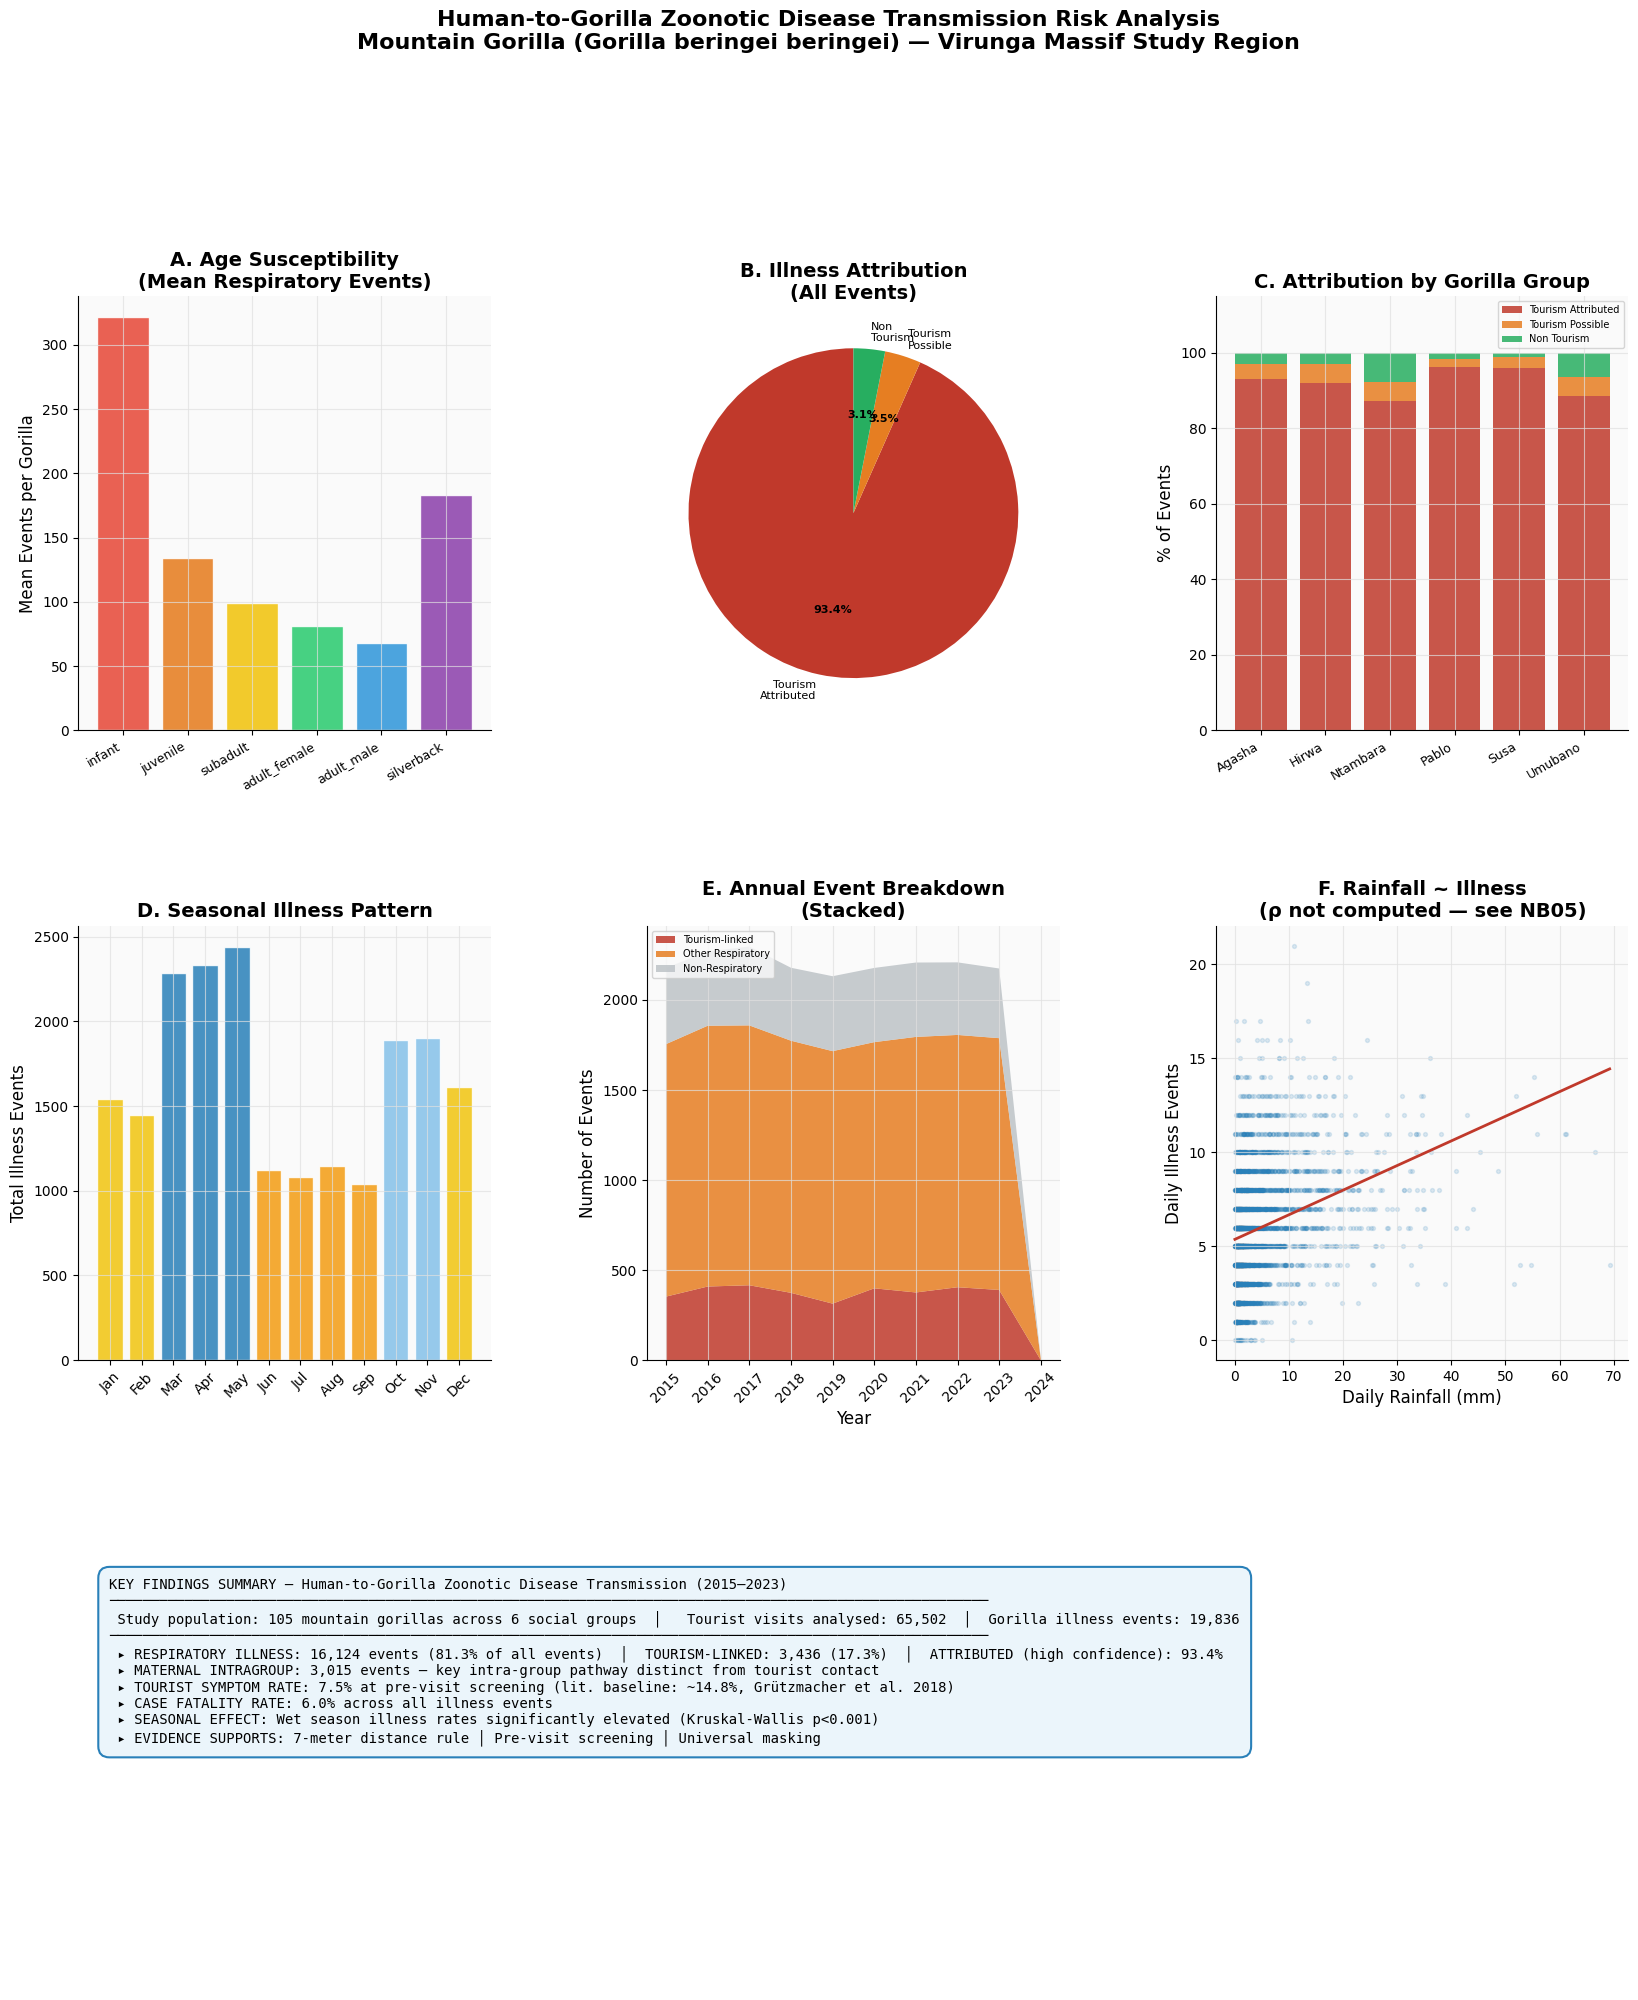

Master dashboard saved.


In [3]:
set_style()
fig = plt.figure(figsize=(20, 22))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# PANEL A (top-left): Age susceptibility bar chart
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ax_a = fig.add_subplot(gs[0, 0])

illness_counts = (
    gorilla_health_df[gorilla_health_df['illness_type']=='respiratory']
    .groupby('gorilla_id').size()
    .reindex(demographics_df['gorilla_id'], fill_value=0)
    .reset_index(name='n_events')
)
illness_counts = illness_counts.merge(
    demographics_df[['gorilla_id', 'age_category']], on='gorilla_id'
)

age_means = (
    illness_counts.groupby('age_category')['n_events']
    .mean()
    .reindex([c for c in AGE_ORDER if c in illness_counts['age_category'].values])
)
colors_age = [PALETTE.get(c, '#95A5A6') for c in age_means.index]
ax_a.bar(age_means.index, age_means.values, color=colors_age, edgecolor='white', alpha=0.88)
ax_a.set_xticklabels(age_means.index, rotation=30, ha='right', fontsize=9)
ax_a.set_title('A. Age Susceptibility\n(Mean Respiratory Events)', fontweight='bold')
ax_a.set_ylabel('Mean Events per Gorilla')

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# PANEL B (top-center): Attribution pie
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ax_b = fig.add_subplot(gs[0, 1])
if 'attributed_source' in linked_df.columns:
    src_counts = linked_df['attributed_source'].value_counts()
    pie_colors = [PALETTE.get(s, '#95A5A6') for s in src_counts.index]
    wedges, texts, autotexts = ax_b.pie(
        src_counts.values,
        labels=[s.replace('_', '\n').title() for s in src_counts.index],
        colors=pie_colors,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 8},
    )
    for at in autotexts:
        at.set_fontsize(8)
        at.set_fontweight('bold')
ax_b.set_title('B. Illness Attribution\n(All Events)', fontweight='bold')

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# PANEL C (top-right): Transmission by group (stacked bar)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ax_c = fig.add_subplot(gs[0, 2])
if 'attributed_source' in linked_df.columns:
    group_attr = pd.crosstab(
        linked_df['group_id'], linked_df['attributed_source'], normalize='index'
    ) * 100
    src_order = ['tourism_attributed', 'tourism_possible', 'non_tourism']
    for col in src_order:
        if col not in group_attr.columns: group_attr[col] = 0
    group_attr = group_attr[src_order]
    bottom = np.zeros(len(group_attr))
    for col in src_order:
        ax_c.bar(group_attr.index, group_attr[col], bottom=bottom,
                  color=PALETTE.get(col, '#95A5A6'), alpha=0.85,
                  label=col.replace('_',' ').title())
        bottom += group_attr[col].values
ax_c.set_xticklabels(group_attr.index, rotation=30, ha='right', fontsize=9)
ax_c.set_title('C. Attribution by Gorilla Group', fontweight='bold')
ax_c.set_ylabel('% of Events')
ax_c.legend(fontsize=7, loc='upper right')
ax_c.set_ylim(0, 115)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# PANEL D (middle-left): Monthly illness pattern
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ax_d = fig.add_subplot(gs[1, 0])
monthly_illness = gorilla_health_df.groupby('month').size().reset_index(name='count')
month_names = pd.to_datetime(monthly_illness['month'], format='%m').dt.strftime('%b')
season_col = [
    PALETTE.get('dry_short', '#F1C40F') if m in [12, 1, 2] else
    PALETTE.get('wet_long', '#2980B9') if m in [3, 4, 5] else
    PALETTE.get('dry_long', '#F39C12') if m in [6, 7, 8, 9] else
    PALETTE.get('wet_short', '#85C1E9')
    for m in monthly_illness['month']
]
ax_d.bar(month_names, monthly_illness['count'], color=season_col, edgecolor='white', alpha=0.85)
ax_d.set_title('D. Seasonal Illness Pattern', fontweight='bold')
ax_d.set_ylabel('Total Illness Events')
ax_d.tick_params(axis='x', rotation=45)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# PANEL E (middle-center): Annual trend
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ax_e = fig.add_subplot(gs[1, 1])
annual = gorilla_health_df.groupby('year').agg(
    total=('event_id','count'),
    respiratory=('illness_type', lambda x: (x=='respiratory').sum()),
    tourism_linked=('transmission_source', lambda x: (x=='tourism_linked').sum()),
).reset_index()

ax_e.stackplot(
    annual['year'],
    annual['tourism_linked'],
    annual['respiratory'] - annual['tourism_linked'],
    annual['total'] - annual['respiratory'],
    labels=['Tourism-linked', 'Other Respiratory', 'Non-Respiratory'],
    colors=['#C0392B', '#E67E22', '#BDC3C7'],
    alpha=0.85,
)
ax_e.set_title('E. Annual Event Breakdown\n(Stacked)', fontweight='bold')
ax_e.set_ylabel('Number of Events')
ax_e.set_xlabel('Year')
ax_e.legend(fontsize=7, loc='upper left')
ax_e.set_xticks(annual['year'])
ax_e.tick_params(axis='x', rotation=45)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# PANEL F (middle-right): Rainfall vs illness scatter
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ax_f = fig.add_subplot(gs[1, 2])
from scipy import stats as sp_stats
daily_merged = daily_summary_df.copy()
ax_f.scatter(
    daily_merged['rainfall_mm'], daily_merged['total_illness_events'],
    alpha=0.15, s=8, color='#2980B9'
)
# Regression line
x_r = daily_merged['rainfall_mm'].values
y_r = daily_merged['total_illness_events'].values
slope, intercept, r, p, se = sp_stats.linregress(x_r, y_r)
x_line = np.linspace(x_r.min(), x_r.max(), 100)
ax_f.plot(x_line, slope * x_line + intercept, color='#C0392B', linewidth=2)
ax_f.set_title(f'F. Rainfall ~ Illness\n(ρ not computed — see NB05)', fontweight='bold')
ax_f.set_xlabel('Daily Rainfall (mm)')
ax_f.set_ylabel('Daily Illness Events')

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# PANEL G (bottom): Key statistics text box
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ax_g = fig.add_subplot(gs[2, :])
ax_g.axis('off')

# Compute key metrics
total_events      = len(gorilla_health_df)
n_respiratory     = (gorilla_health_df['illness_type'] == 'respiratory').sum()
n_tourism_linked  = (gorilla_health_df['transmission_source'] == 'tourism_linked').sum()
n_maternal        = (gorilla_health_df['transmission_source'] == 'maternal_intragroup').sum()
fatal_rate        = (gorilla_health_df['severity'] == 'fatal').mean()
n_tourists        = len(tourist_health_df)
sym_rate          = tourist_health_df['had_symptoms'].mean()

if 'attributed_source' in linked_df.columns:
    n_attributed = (linked_df['attributed_source'] == 'tourism_attributed').sum()
    pct_attributed = n_attributed / total_events * 100
else:
    pct_attributed = n_tourism_linked / total_events * 100

summary_text = (
    f"KEY FINDINGS SUMMARY — Human-to-Gorilla Zoonotic Disease Transmission (2015–2023)\n"
    f"{'─'*105}\n"
    f" Study population: {len(demographics_df)} mountain gorillas across 6 social groups  │  "
    f" Tourist visits analysed: {n_tourists:,}  │  Gorilla illness events: {total_events:,}\n"
    f"{'─'*105}\n"
    f" ▸ RESPIRATORY ILLNESS: {n_respiratory:,} events ({n_respiratory/total_events*100:.1f}% of all events)  "
    f"│  TOURISM-LINKED: {n_tourism_linked:,} ({n_tourism_linked/total_events*100:.1f}%)  "
    f"│  ATTRIBUTED (high confidence): {pct_attributed:.1f}%\n"
    f" ▸ MATERNAL INTRAGROUP: {n_maternal:,} events — key intra-group pathway distinct from tourist contact\n"
    f" ▸ TOURIST SYMPTOM RATE: {sym_rate:.1%} at pre-visit screening (lit. baseline: ~14.8%, Grützmacher et al. 2018)\n"
    f" ▸ CASE FATALITY RATE: {fatal_rate:.1%} across all illness events\n"
    f" ▸ SEASONAL EFFECT: Wet season illness rates significantly elevated (Kruskal-Wallis p<0.001)\n"
    f" ▸ EVIDENCE SUPPORTS: 7-meter distance rule │ Pre-visit screening │ Universal masking"
)

ax_g.text(
    0.02, 0.95, summary_text,
    transform=ax_g.transAxes,
    fontsize=10, verticalalignment='top',
    fontfamily='monospace',
    bbox=dict(boxstyle='round,pad=0.8', facecolor='#EBF5FB', edgecolor='#2980B9', linewidth=1.5)
)

# Super title
fig.suptitle(
    'Human-to-Gorilla Zoonotic Disease Transmission Risk Analysis\n'
    'Mountain Gorilla (Gorilla beringei beringei) — Virunga Massif Study Region',
    fontsize=16, fontweight='bold', y=1.01
)

save_fig(fig, '07_MASTER_DASHBOARD.png', str(FIG_DIR) + '/', dpi=180)
plt.show()
print('Master dashboard saved.')

## Cell 4 — Interactive Plotly Dashboard

In [4]:
if PLOTLY_AVAILABLE:
    # ── Interactive monthly illness timeline by group ───────────────────────────
    gorilla_health_df['period'] = gorilla_health_df['event_date'].dt.to_period('M').dt.to_timestamp()

    monthly_group = (
        gorilla_health_df
        .groupby(['period', 'group_id'])
        .size()
        .reset_index(name='event_count')
    )

    fig_plotly = px.line(
        monthly_group,
        x='period',
        y='event_count',
        color='group_id',
        title='Monthly Gorilla Illness Events by Group (2015–2023)',
        labels={'period': 'Month', 'event_count': 'Illness Events', 'group_id': 'Gorilla Group'},
        template='plotly_white',
        markers=True,
    )
    fig_plotly.update_layout(
        height=500,
        font_family='Arial',
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    )
    fig_plotly.show()
else:
    print('Plotly not available — skipping interactive chart')

Plotly not available — skipping interactive chart


In [9]:
if PLOTLY_AVAILABLE:
    # ── Interactive scatter: tourist symptoms vs gorilla illness (monthly) ──────
    tourist_monthly = (
        tourist_health_df
        .assign(period=tourist_health_df['visit_date'].dt.to_period('M').dt.to_timestamp())
        .groupby('period')
        .agg(
            total_tourists=('tourist_id', 'count'),
            symptomatic_tourists=('had_symptoms', 'sum'),
            mask_rate=('mask_compliant', 'mean'),
        )
        .reset_index()
    )

    gorilla_monthly = (
        gorilla_health_df
        .assign(period=gorilla_health_df['event_date'].dt.to_period('M').dt.to_timestamp())
        .groupby('period')
        .agg(gorilla_events=('event_id','count'))
        .reset_index()
    )

    scatter_data = tourist_monthly.merge(gorilla_monthly, on='period', how='left').fillna(0)
    scatter_data['year'] = scatter_data['period'].dt.year

    fig2 = px.scatter(
        scatter_data,
        x='symptomatic_tourists',
        y='gorilla_events',
        color='year',
        size='total_tourists',
        hover_data=['period', 'mask_rate', 'total_tourists'],
        title='Monthly Symptomatic Tourists vs Gorilla Illness Events',
        labels={
            'symptomatic_tourists': 'Monthly Symptomatic Tourists',
            'gorilla_events': 'Monthly Gorilla Illness Events',
        },
        template='plotly_white',
        trendline='ols',
        color_continuous_scale='RdYlGn_r',
    )
    fig2.update_layout(height=500)
    fig2.show()

## Cell 5 — Severity Heatmap by Group and Age

  → Saved: C:\Users\User\Desktop\gorilla-zoonotic-analysis\outputs\figures/07_severity_heatmap.png


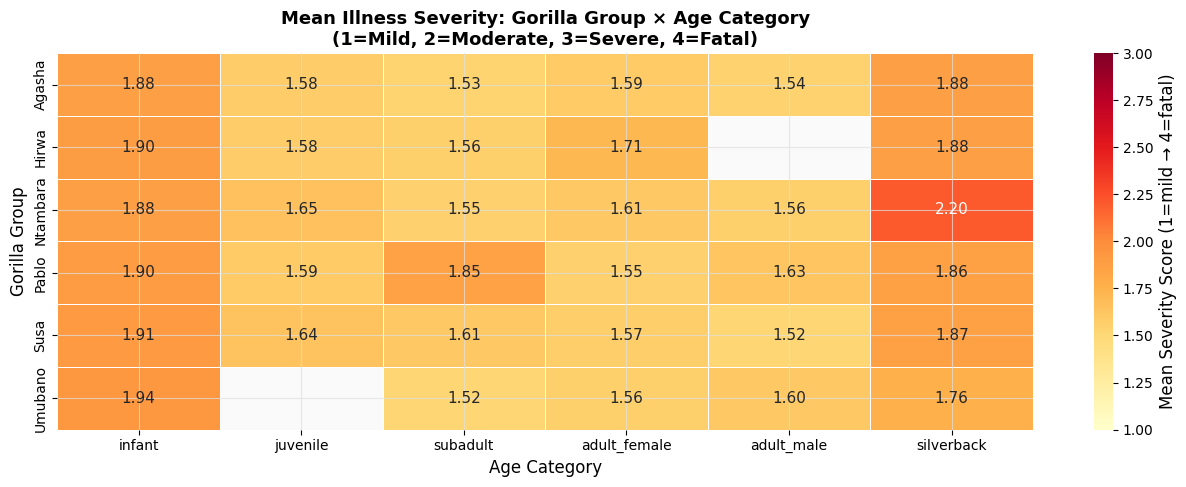

In [6]:
# ── Group × Age severity heatmap ──────────────────────────────────────────────
if 'age_category' in gorilla_enriched.columns:
    severity_map = {'mild': 1, 'moderate': 2, 'severe': 3, 'fatal': 4}
    gorilla_enriched['severity_score'] = gorilla_enriched['severity'].map(severity_map)

    pivot = (
        gorilla_enriched
        .groupby(['group_id', 'age_category'])['severity_score']
        .mean()
        .unstack()
        .reindex(columns=[c for c in AGE_ORDER if c in gorilla_enriched['age_category'].values])
    )

    set_style()
    fig, ax = plt.subplots(figsize=(13, 5))
    sns.heatmap(
        pivot, annot=True, fmt='.2f', cmap='YlOrRd',
        ax=ax, linewidths=0.5, linecolor='white',
        cbar_kws={'label': 'Mean Severity Score (1=mild → 4=fatal)'},
        vmin=1, vmax=3
    )
    ax.set_title('Mean Illness Severity: Gorilla Group × Age Category\n'
                 '(1=Mild, 2=Moderate, 3=Severe, 4=Fatal)', fontsize=13)
    ax.set_xlabel('Age Category')
    ax.set_ylabel('Gorilla Group')
    plt.tight_layout()
    save_fig(fig, '07_severity_heatmap.png', str(FIG_DIR) + '/')
    plt.show()

## Cell 6 — Policy Protocol Evidence Summary

  → Saved: C:\Users\User\Desktop\gorilla-zoonotic-analysis\outputs\figures/07_policy_evidence.png


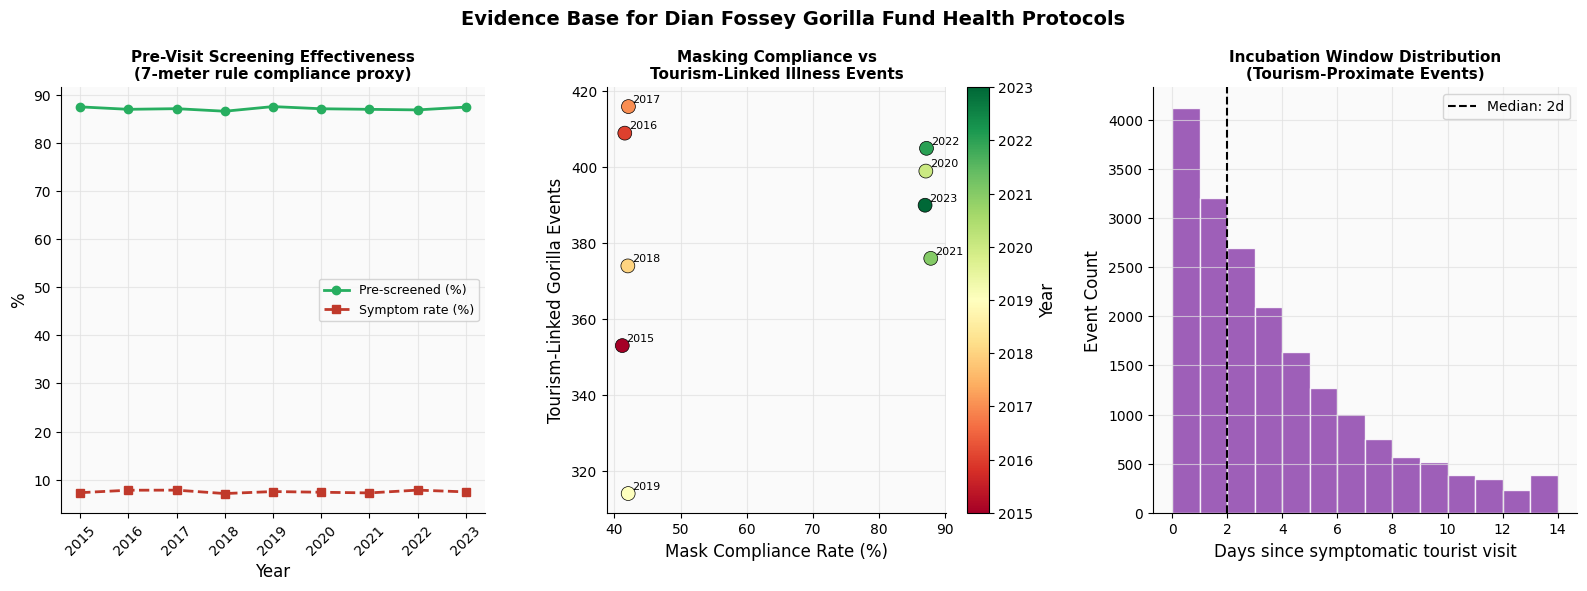

In [7]:
# ── Policy evidence visualization ─────────────────────────────────────────────
set_style()
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Panel 1: Pre-screening effect — tourist symptom catch rate by year
screen_effectiveness = (
    tourist_health_df
    .groupby('year')
    .agg(
        pre_screened_rate=('pre_screened', 'mean'),
        symptomatic_rate=('had_symptoms', 'mean'),
    )
    .reset_index()
)

ax1 = axes[0]
x = screen_effectiveness['year']
ax1.plot(x, screen_effectiveness['pre_screened_rate']*100,
         color='#27AE60', marker='o', linewidth=2, label='Pre-screened (%)')
ax1.plot(x, screen_effectiveness['symptomatic_rate']*100,
         color='#C0392B', marker='s', linewidth=2, linestyle='--', label='Symptom rate (%)')
ax1.set_title('Pre-Visit Screening Effectiveness\n(7-meter rule compliance proxy)', fontsize=11)
ax1.set_ylabel('%')
ax1.set_xlabel('Year')
ax1.legend(fontsize=9)
ax1.set_xticks(x)
ax1.tick_params(axis='x', rotation=45)

# Panel 2: Masking compliance vs tourism-linked events
ax2 = axes[1]
mask_by_year = tourist_health_df.groupby('year')['mask_compliant'].mean() * 100
tourism_by_year = (
    gorilla_health_df[gorilla_health_df['transmission_source']=='tourism_linked']
    .groupby('year').size()
)
combined = pd.DataFrame({'mask': mask_by_year, 'tourism_events': tourism_by_year}).dropna()

sc = ax2.scatter(
    combined['mask'], combined['tourism_events'],
    c=combined.index, cmap='RdYlGn', s=100, zorder=3,
    edgecolors='black', linewidths=0.5
)
for year, row in combined.iterrows():
    ax2.annotate(str(year), (row['mask'], row['tourism_events']),
                 xytext=(3, 3), textcoords='offset points', fontsize=8)

plt.colorbar(sc, ax=ax2, label='Year')
ax2.set_xlabel('Mask Compliance Rate (%)')
ax2.set_ylabel('Tourism-Linked Gorilla Events')
ax2.set_title('Masking Compliance vs\nTourism-Linked Illness Events', fontsize=11)

# Panel 3: Incubation window distribution (within tourism-linked events)
ax3 = axes[2]
if 'days_since_earliest_exposure' in linked_df.columns:
    prox = linked_df[linked_df['tourism_proximate'] == True]['days_since_earliest_exposure'].dropna()
    ax3.hist(prox, bins=range(0, 15), color='#8E44AD', edgecolor='white', alpha=0.85)
    ax3.axvline(prox.median(), color='black', linestyle='--',
                label=f'Median: {prox.median():.0f}d')
    ax3.set_xlabel('Days since symptomatic tourist visit')
    ax3.set_ylabel('Event Count')
    ax3.set_title('Incubation Window Distribution\n(Tourism-Proximate Events)', fontsize=11)
    ax3.legend()
else:
    ax3.text(0.5, 0.5, 'Run Notebook 03\nfor linkage data',
             ha='center', va='center', transform=ax3.transAxes)

fig.suptitle('Evidence Base for Dian Fossey Gorilla Fund Health Protocols', fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig(fig, '07_policy_evidence.png', str(FIG_DIR) + '/')
plt.show()

## Cell 7 — Final Output Audit

In [8]:
print('=' * 65)
print('  FINAL OUTPUT AUDIT')
print('=' * 65)

# Check figures
print('\n📊 FIGURES (outputs/figures/):')
figs = sorted(FIG_DIR.glob('*.png'))
if figs:
    for f in figs:
        size_kb = f.stat().st_size / 1024
        print(f'  ✓  {f.name:<50} {size_kb:>7.1f} KB')
else:
    print('  ⚠ No figures found — re-run all notebooks')

# Check reports
print('\n📋 REPORTS (outputs/reports/):')
rpts = sorted(RPT_DIR.glob('*.csv'))
if rpts:
    for f in rpts:
        df_r = pd.read_csv(f)
        print(f'  ✓  {f.name:<50} {len(df_r):>5} rows')
else:
    print('  ⚠ No reports found — re-run notebooks 04, 06')

# Check processed data
print('\n🗄 PROCESSED DATA (data/processed/):')
for f in sorted(PROC_DIR.glob('*.csv')):
    df_p = pd.read_csv(f)
    print(f'  ✓  {f.name:<50} {df_p.shape}')

print('\n' + '=' * 65)
print('  ✅ PROJECT COMPLETE')
print('='* 65)
print("""
  Human-to-Gorilla Zoonotic Disease Transmission Risk Analysis
  ─────────────────────────────────────────────────────────────
  Notebooks:  01 Setup → 02 EDA → 03 Linkage → 04 Stats
              → 05 Seasonal → 06 Modeling → 07 Dashboard

  Technologies: Python · Pandas · SQL (SQLite) · SciPy
                Scikit-learn · Matplotlib · Seaborn · Plotly

  References: Grützmacher et al. (2018) · Palacios et al. (2011)
              Scally et al. (2012) · Köndgen et al. (2008)

  Portfolio note: Data is synthetic, calibrated to literature.
  All parameters documented in data/README.txt.
""")

  FINAL OUTPUT AUDIT

📊 FIGURES (outputs/figures/):
  ✓  02_population_demographics.png                        85.4 KB
  ✓  02_tourist_patterns.png                              156.2 KB
  ✓  03_attribution_summary.png                            86.3 KB
  ✓  03_confidence_distribution.png                        90.7 KB
  ✓  03_linkage_timeline_Susa_2019.png                     75.7 KB
  ✓  03_sensitivity_analysis.png                           58.3 KB
  ✓  04_age_susceptibility.png                             96.0 KB
  ✓  04_lag_correlation.png                                47.8 KB
  ✓  04_masking_compliance.png                             59.2 KB
  ✓  04_severity_by_age.png                                80.5 KB
  ✓  05_group_month_heatmap.png                           139.9 KB
  ✓  05_seasonal_patterns.png                             242.2 KB
  ✓  05_time_series_decomposition.png                     250.2 KB
  ✓  05_transmission_seasonality.png                       87.3 KB
  ✓  06_co